<!-- @q -->
## Problem 1 

Using the data in the `2019_Yellow_Taxi_Trip_Data.csv` file, calculate summary statistics for the `fare_amount`, `tip_amount`, `tolls_amount`, and `total_amount` columns:

In [1]:
import numpy as num
import pandas as pd
import matplotlib as mat

df1 = pd.read_csv ("data/2019_Yellow_Taxi_Trip_Data.csv")
df1.head

df1[["fare_amount","tip_amount","tolls_amount","total_amount"]].describe()

,fare_amount,tip_amount,tolls_amount,total_amount
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,15.106313,2.634494,0.623447,22.564659
std,13.954762,3.409800,6.437507,19.209255
min,-52.000000,0.000000,-6.120000,-65.920000
25%,7.000000,0.000000,0.000000,12.375000
50%,10.000000,2.000000,0.000000,16.300000
75%,16.000000,3.250000,0.000000,22.880000
max,176.000000,43.000000,612.000000,671.800000


<!-- @q -->
## Problem 2

Isolate the `fare_amount`, `tip_amount`, `tolls_amount`, and `total_amount` for the longest trip by distance (`trip_distance`):

In [2]:
longest = df1.loc[df1["trip_distance"].idxmax()]
longest[["fare_amount","tip_amount","tolls_amount","total_amount"]]

fare_amount      176.0
tip_amount       18.29
tolls_amount      6.12
total_amount    201.21
Name: 8338, dtype: object

<!-- @q -->
## Problem 3 

Read in the meteorite data from the `Meteorite_Landings.csv` file, rename the `mass (g)` column to `mass`, and drop all the latitude and longitude columns. Sort the result by mass in descending order.

In [3]:

df2 = pd.read_csv("data/Meteorite_Landings.csv")
final = df2.rename(columns={"mass (g)" : "mass"})
final1 = final.drop(columns=["reclat", "reclong", "GeoLocation"], errors="ignore")
final1 = final1.sort_values(by="mass", ascending=False)
final1

,name,id,nametype,recclass,mass,fall,year
16392,Hoba,11890,Valid,"Iron, IVB",60000000.0,Found,01/01/1920 12:00:00 AM
5373,Cape York,5262,Valid,"Iron, IIIAB",58200000.0,Found,01/01/1818 12:00:00 AM
5365,Campo del Cielo,5247,Valid,"Iron, IAB-MG",50000000.0,Found,12/22/1575 12:00:00 AM
5370,Canyon Diablo,5257,Valid,"Iron, IAB-MG",30000000.0,Found,01/01/1891 12:00:00 AM
3455,Armanty,2335,Valid,"Iron, IIIE",28000000.0,Found,01/01/1898 12:00:00 AM
...,...,...,...,...,...,...,...
38282,Wei-hui-fu (a),24231,Valid,Iron,NaN,Found,01/01/1931 12:00:00 AM
38283,Wei-hui-fu (b),24232,Valid,Iron,NaN,Found,01/01/1931 12:00:00 AM
38285,Weiyuan,24233,Valid,Mesosiderite,NaN,Found,01/01/1978 12:00:00 AM
41472,Yamato 792768,28117,Valid,CM2,NaN,Found,01/01/1979 12:00:00 AM


<!-- @q -->
## Problem 4

Using the meteorite data from the `Meteorite_Landings.csv` file, update the `year` column to only contain the year, convert it to a numeric data type, and create a new column indicating whether the meteorite was observed falling before 1970. Set the index to the `id` column and extract all the rows with IDs between 10,036 and 10,040 (inclusive) with `loc[]`.

**Hint 1**: Use `year.str.slice()` to grab a substring.

**Hint 2**: Make sure to sort the index before using `loc[]` to select the range.

In [4]:
df2 = pd.read_csv("data/Meteorite_Landings.csv")

df2["year"] = df2["year"].str.slice(6, 10)

df2["year"] = pd.to_numeric(df2["year"], errors="coerce")

df2["observed_before_1970"] = df2["year"] < 1970

df2 = df2.set_index("id")

df2 = df2.sort_index()

subset = df2.loc[10036:10040]

df2

,name,nametype,recclass,mass (g),fall,year,reclat,reclong,GeoLocation,observed_before_1970
id,,,,,,,,,,
1,Aachen,Valid,L5,21.0,Fell,1880.0,50.77500,6.08333,"(50.775, 6.08333)",True
2,Aarhus,Valid,H6,720.0,Fell,1951.0,56.18333,10.23333,"(56.18333, 10.23333)",True
4,Abajo,Valid,H5,331.0,Found,1982.0,26.80000,-105.41667,"(26.8, -105.41667)",False
5,Abbott,Valid,H3-6,21100.0,Found,1951.0,36.30000,-104.28333,"(36.3, -104.28333)",True
6,Abee,Valid,EH4,107000.0,Fell,1952.0,54.21667,-113.00000,"(54.21667, -113.0)",True
...,...,...,...,...,...,...,...,...,...,...
57454,Mandalay Spring,Valid,L6,2854.0,Found,2012.0,40.89201,-118.55319,"(40.89201, -118.55319)",False
57455,Antelope,Valid,H4,754.0,Found,2012.0,40.90183,-118.54465,"(40.90183, -118.54465)",False
57456,Northwest Africa 7870,Valid,L4,42.0,Found,2004.0,0.00000,0.00000,"(0.0, 0.0)",False


**BONUS**: There's a data entry error in the `year` column. Can you find it?

In [5]:
# Your code here

There's a meteorite that was reportedly found in the future:

In [6]:
# Your code here


_This meteorite actually was found in 2010 (more information [here](https://www.lpi.usra.edu/meteor/metbull.php?code=57150))._

<!-- @q -->
## Problem 5

Using the taxi trip data in the `2019_Yellow_Taxi_Trip_Data.csv` file, resample the data to an hourly frequency based on the dropoff time. Calculate the total `trip_distance`, `fare_amount`, `tolls_amount`, and `tip_amount`, then find the 5 hours with the most tips.

In [7]:
df1 = pd.read_csv ("data/2019_Yellow_Taxi_Trip_Data.csv") 

df1["tpep_dropoff_datetime"] = pd.to_datetime(df1["tpep_dropoff_datetime"], errors= "coerce")

df1 = df1.set_index("tpep_dropoff_datetime")

hourly = df1.resample("H").agg({"trip_distance": "sum","fare_amount": "sum", "tolls_amount": "sum" ,"tip_amount": "sum" })

top_hours = hourly.sort_values(by="tip_amount").head(5)

print(top_hours)








                       trip_distance  fare_amount  tolls_amount  tip_amount
tpep_dropoff_datetime                                                      
2019-10-23 07:00:00             0.67          4.5           0.0         0.0
2019-10-23 09:00:00             1.58         58.0           0.0         0.0
2019-10-23 10:00:00             0.00          0.0           0.0         0.0
2019-10-23 11:00:00             0.00          0.0           0.0         0.0
2019-10-23 22:00:00             0.00          0.0           0.0         0.0


/tmp/ipykernel_55885/3287906360.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly = df1.resample("H").agg({"trip_distance": "sum","fare_amount": "sum", "tolls_amount": "sum" ,"tip_amount": "sum" })


<!-- @q -->
## Problem 6

Using the TSA traveler throughput data in the `tsa_melted_holiday_travel.csv` file, create box plots for traveler throughput for each year in the data. Hint: Pass `kind='box'` into the `plot()` method to generate box plots.

travelers    Axes(0.125,0.11;0.775x0.77)
dtype: object

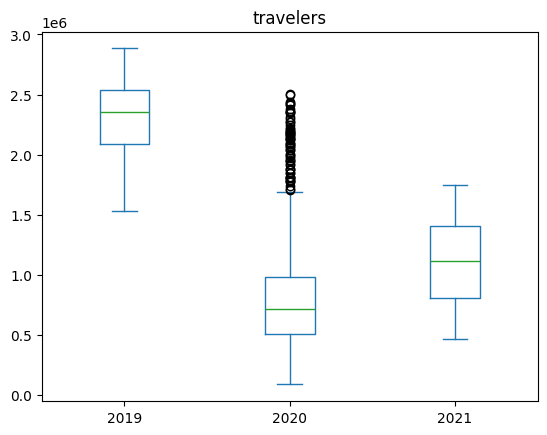

In [8]:
df3 = pd.read_csv("data/tsa_melted_holiday_travel.csv")

df3

df3.plot(kind='box', column='travelers', by='year')



<!-- @q -->
## Problem 7
Using the TSA traveler throughput data in the `tsa_melted_holiday_travel.csv` file, create a heatmap that shows the 2019 TSA median traveler throughput by day of week and month.

In [9]:
df_2019 = df3[df3['year'] == 2019]

